# 🏥 Lab 7: CT Reconstruction
## From X-Ray Projections to Tomographic Images

**AI in Medicine and Healthcare**  
**Prof. Dr. Marcel P. Jackowski**  
**Class 7: X-ray Computed Tomography**

---

## 📝 Student Information

**Student 1:**
- Name: Bruno Olivares
- Email: brunoos@al.insper.edu.br

**Student 2:**
- Name: _______________________
- Email: ______________________

**Date:** 05/03

---

## 🎯 Lab Objectives

Today you will implement CT reconstruction algorithms:

1. **Generate multiple X-ray projections** at different angles
2. **Create a sinogram** from projections (Radon transform)
3. **Implement simple backprojection** reconstruction
4. **Implement filtered backprojection** (FBP)
5. **Compare reconstruction quality**

**Connection to Lab 7:**
- Lab 6: Created **ONE** X-ray projection (Beer-Lambert Law)
- Lab 7: Use **MANY** projections to reconstruct the image!

---

# 🚀 Setup

In [38]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
%matplotlib inline

# Random seed
np.random.seed(42)

print('✓ Libraries loaded successfully!')
print(f'NumPy version: {np.__version__}')

✓ Libraries loaded successfully!
NumPy version: 2.0.2


---

# 📁 Load Test Images

We'll use the **same phantoms from Lab 6**!

**Note:** Make sure you have the `test_images/` folder from Lab 6.

In [39]:
# Download and extract dataset
!gdown 1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
!unzip -q xray_test_images.zip

print("✓ Dataset ready!")

Downloading...
From: https://drive.google.com/uc?id=1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
To: /content/xray_test_images.zip
100% 659k/659k [00:00<00:00, 133MB/s]
replace test_images/angio_phantom.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✓ Dataset ready!


Test images loaded:
  Simple phantom: (256, 256)
  Hand phantom:   (300, 250)
  Chest phantom:  (400, 350)


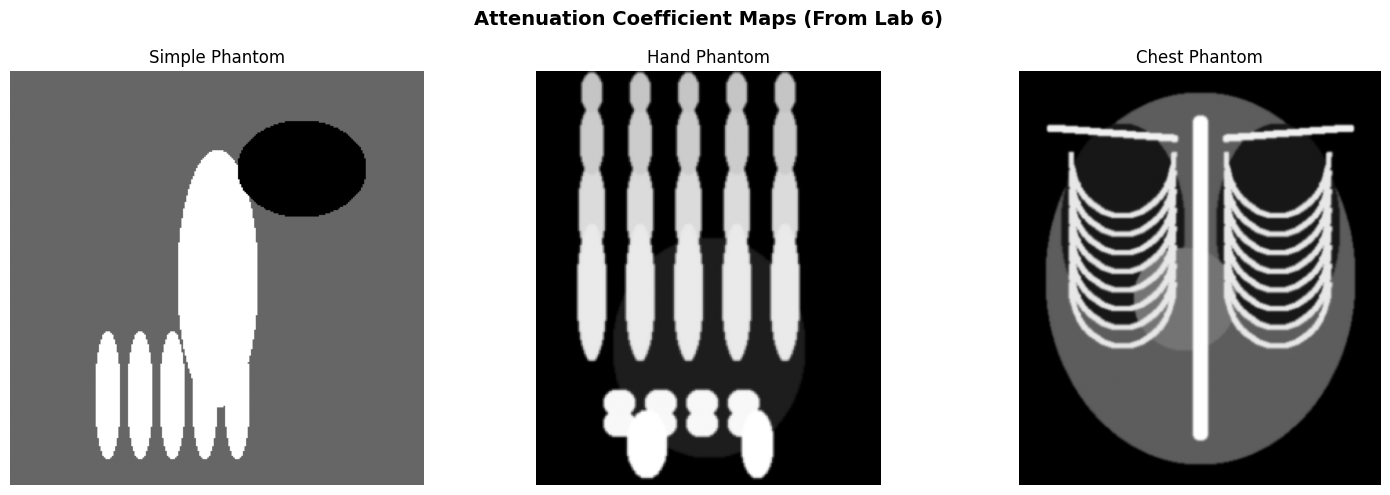


💡 These are μ (attenuation) maps, NOT X-ray images yet!


In [40]:
# Load phantoms from Lab 5
phantom_simple = np.load('test_images/phantom_simple.npy')
hand_phantom = np.load('test_images/hand_phantom.npy')
chest_phantom = np.load('test_images/chest_phantom.npy')

print('Test images loaded:')
print(f'  Simple phantom: {phantom_simple.shape}')
print(f'  Hand phantom:   {hand_phantom.shape}')
print(f'  Chest phantom:  {chest_phantom.shape}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Simple Phantom', fontsize=12)
axes[0].axis('off')

axes[1].imshow(hand_phantom, cmap='gray')
axes[1].set_title('Hand Phantom', fontsize=12)
axes[1].axis('off')

axes[2].imshow(chest_phantom, cmap='gray')
axes[2].set_title('Chest Phantom', fontsize=12)
axes[2].axis('off')

plt.suptitle('Attenuation Coefficient Maps (From Lab 6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 These are μ (attenuation) maps, NOT X-ray images yet!')

---

# 📡 PART 1: Create Projections & Sinogram (25 min)

## Background

**On Tuesday (Lab 6):** You created ONE X-ray projection using Beer-Lambert Law

**Today:** We'll create MANY projections at different angles!

### Radon Transform
The **Radon transform** computes projections of an image at specified angles.

**Projection P(θ,t):** Sum of attenuation values along rays at angle θ

**Sinogram:** Stack of all projections (one row per angle)

---

## Step 1.1: Generate Sinogram

**TODO:** Create projections at different angles and build sinogram

In [41]:
import skimage as ski

def create_sinogram(phantom, num_angles=180):

    """
    Create sinogram from phantom using Radon transform.

    Parameters:
    -----------
    phantom : 2D array
        Attenuation coefficient map
    num_angles : int
        Number of projection angles (default: 180)

    Returns:
    --------
    sinogram : 2D array
        Sinogram (projections x detector)
    theta : 1D array
        Projection angles in degrees
    """

    # TODO: Create array of angles from 0 to 180 degrees
    theta = np.linspace(0, num_angles, num = 180)  # Use np.linspace

    # TODO: Compute Radon transform (sinogram)
    # Hint: Look up the scikit-image documentation for the appropriate function
    sinogram = ski.transform.radon(phantom, theta)

    return sinogram, theta

# Test with simple phantom
sinogram_simple, angles = create_sinogram(phantom_simple, num_angles=180)

print(f'Sinogram shape: {sinogram_simple.shape}')
print(f'Number of angles: {len(angles)}')
print(f'Angle range: {angles.min():.1f}° to {angles.max():.1f}°')

Sinogram shape: (256, 180)
Number of angles: 180
Angle range: 0.0° to 180.0°


## Step 1.2: Visualize Sinogram

**TODO:** Display the phantom and its sinogram side by side

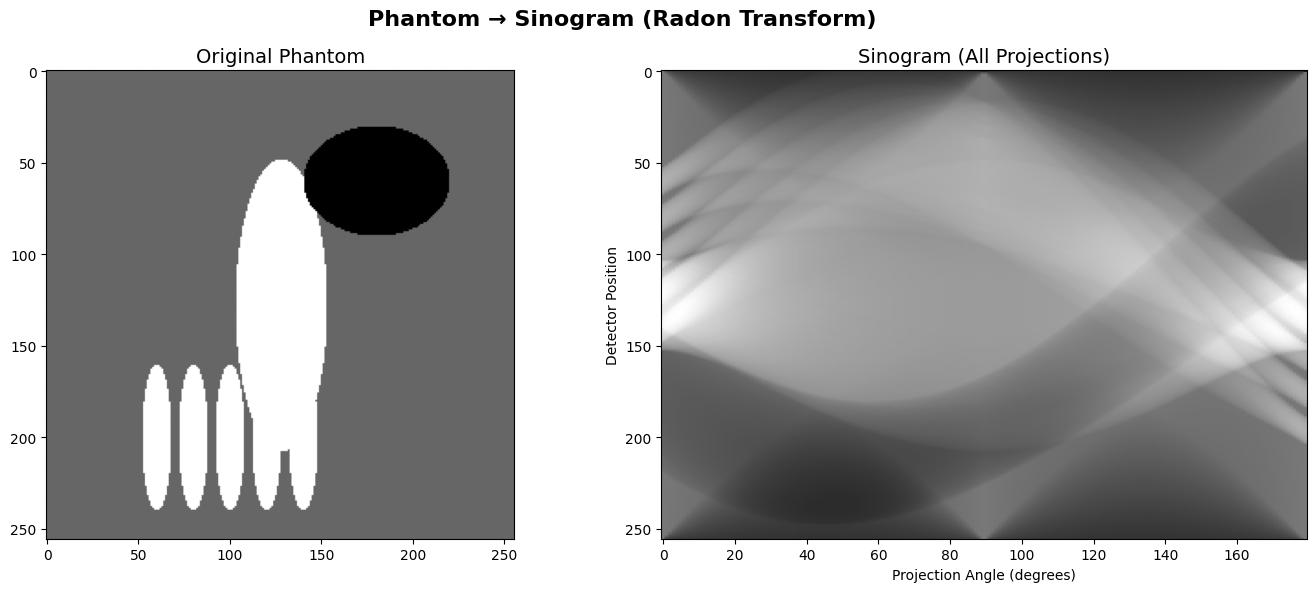


💡 Sinogram: Each row is one projection at a specific angle
   Bright = high attenuation, Dark = low attenuation


In [42]:
# TODO: Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original phantom
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Original Phantom', fontsize=14)

# Sinogram
axes[1].imshow(sinogram_simple, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram (All Projections)', fontsize=14)
axes[1].set_ylabel('Detector Position')
axes[1].set_xlabel('Projection Angle (degrees)')

plt.suptitle('Phantom → Sinogram (Radon Transform)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Sinogram: Each row is one projection at a specific angle')
print('   Bright = high attenuation, Dark = low attenuation')

## Step 1.3: Visualize Individual Projections

Let's see what projections at different angles look like!

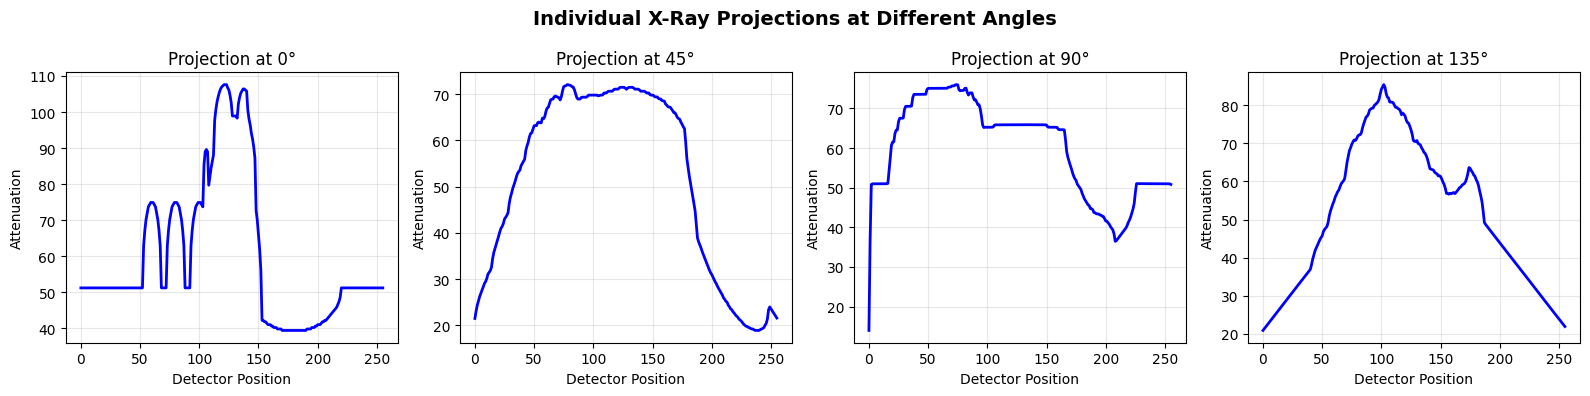

✓ Each projection captures the object from a different angle


In [43]:
# Show projections at 0°, 45°, 90°, 135°
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
angles_to_show = [0, 45, 90, 135]

for i, angle in enumerate(angles_to_show):
    angle_idx = int(angle)
    projection = sinogram_simple[:, angle_idx]

    axes[i].plot(projection, 'b-', linewidth=2)
    axes[i].set_title(f'Projection at {angle}°', fontsize=12)
    axes[i].set_xlabel('Detector Position')
    axes[i].set_ylabel('Attenuation')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Individual X-Ray Projections at Different Angles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Each projection captures the object from a different angle')

## Step 1.4: Create Sinograms for All Phantoms

**TODO:** Generate sinograms for hand and chest phantoms

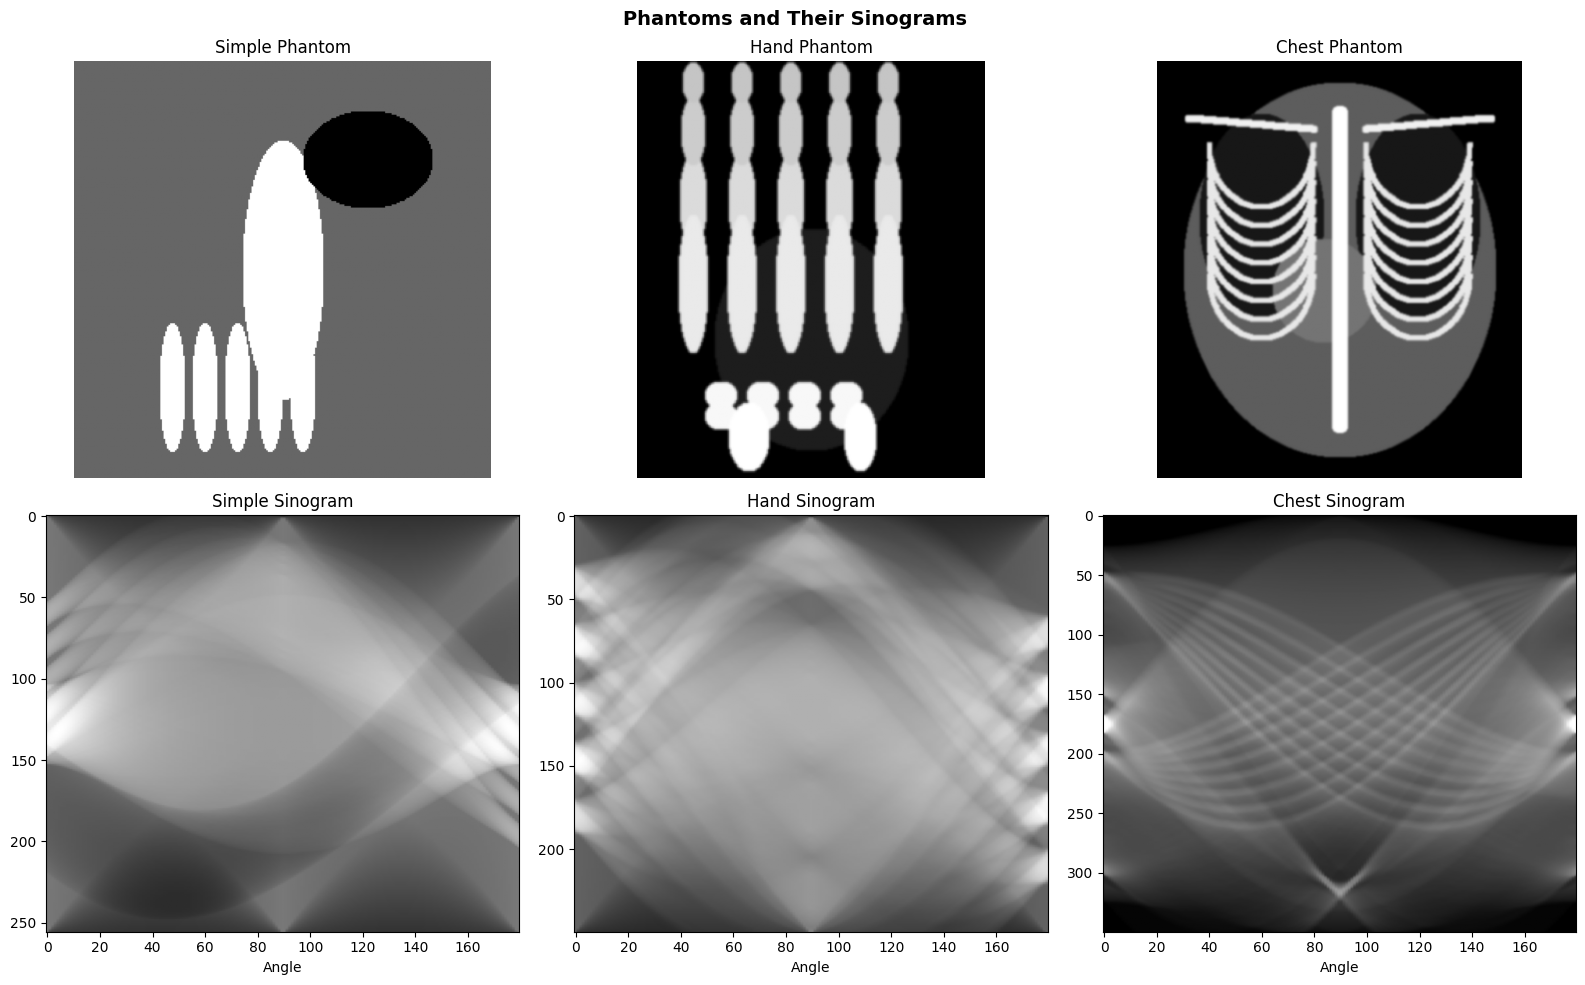

✓ Part 1 Complete! Sinograms created for all phantoms.


In [44]:
# TODO: Create sinograms
sinogram_hand, _ = create_sinogram(hand_phantom)
sinogram_chest, _ = create_sinogram(chest_phantom)

# Visualize all three
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Phantoms
axes[0, 0].imshow(phantom_simple, cmap='gray')
axes[0, 0].set_title('Simple Phantom', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hand_phantom, cmap='gray')
axes[0, 1].set_title('Hand Phantom', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(chest_phantom, cmap='gray')
axes[0, 2].set_title('Chest Phantom', fontsize=12)
axes[0, 2].axis('off')

# Row 2: Sinograms
axes[1, 0].imshow(sinogram_simple, cmap='gray', aspect='auto')
axes[1, 0].set_title('Simple Sinogram', fontsize=12)
axes[1, 0].set_xlabel('Angle')

axes[1, 1].imshow(sinogram_hand, cmap='gray', aspect='auto')
axes[1, 1].set_title('Hand Sinogram', fontsize=12)
axes[1, 1].set_xlabel('Angle')

axes[1, 2].imshow(sinogram_chest, cmap='gray', aspect='auto')
axes[1, 2].set_title('Chest Sinogram', fontsize=12)
axes[1, 2].set_xlabel('Angle')

plt.suptitle('Phantoms and Their Sinograms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Part 1 Complete! Sinograms created for all phantoms.')

## 🎉 Part 1 Complete!

**What you learned:**
- ✅ Radon transform creates projections
- ✅ Sinogram = stack of all projections
- ✅ Each row = one angle
- ✅ Foundation for CT reconstruction!

**Key insight:** The sinogram contains ALL information needed to reconstruct the image!

---

# 🔄 PART 2: Simple Backprojection (20 min)

## Background

**Backprojection:** 'Smear' each projection back across the image

**Problem:** Creates blurry images with star artifacts!

**Process:**
1. Take one projection
2. Spread it back along the same angle
3. Repeat for all angles
4. Sum all backprojections

---

## Step 2.1: Implement Simple Backprojection

**TODO:** Reconstruct image using simple backprojection

In [45]:
def simple_backprojection(sinogram, theta):
    """
    Reconstruct image using simple backprojection.

    Parameters:
    -----------
    sinogram : 2D array
        Input sinogram
    theta : 1D array
        Projection angles

    Returns:
    --------
    reconstruction : 2D array
        Reconstructed image
    """

    # Hint: Look up the scikit-image documentation for the appropriate function
    reconstruction = ski.transform.iradon(sinogram, theta)

    return reconstruction

# Test
recon_simple_bp = simple_backprojection(sinogram_simple, angles)

print(f'Reconstruction shape: {recon_simple_bp.shape}')
print(f'Value range: [{recon_simple_bp.min():.3f}, {recon_simple_bp.max():.3f}]')

Reconstruction shape: (256, 256)
Value range: [-0.126, 1.070]


## Step 2.2: Visualize Simple Backprojection Result

**TODO:** Compare original phantom with backprojection reconstruction

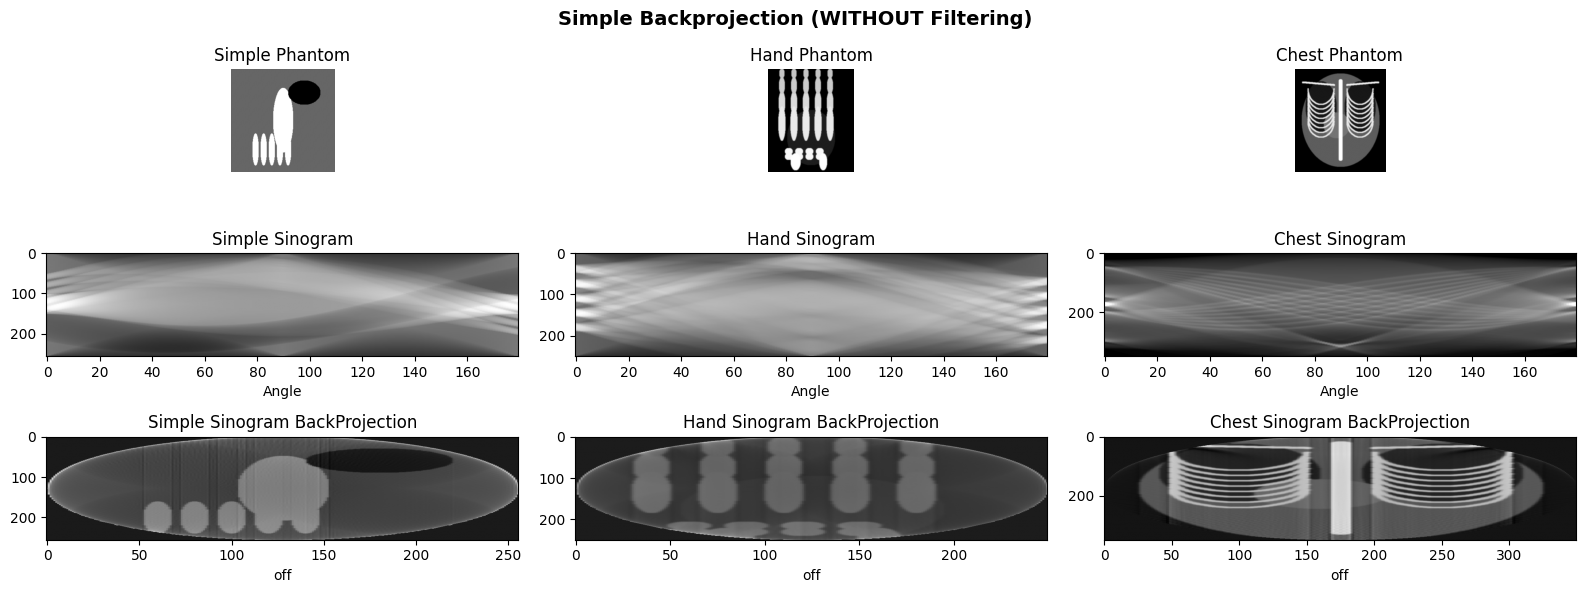


❌ Notice: Image is BLURRY with star artifacts!
💡 This is why we need FILTERING!


In [46]:
# TODO: Create comparison plot
fig, axes = plt.subplots(3, 3, figsize=(16, 6))

# Row 1: Phantoms
axes[0, 0].imshow(phantom_simple, cmap='gray')
axes[0, 0].set_title('Simple Phantom', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hand_phantom, cmap='gray')
axes[0, 1].set_title('Hand Phantom', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(chest_phantom, cmap='gray')
axes[0, 2].set_title('Chest Phantom', fontsize=12)
axes[0, 2].axis('off')

# Row 2: Sinograms
axes[1, 0].imshow(sinogram_simple, cmap='gray', aspect='auto')
axes[1, 0].set_title('Simple Sinogram', fontsize=12)
axes[1, 0].set_xlabel('Angle')

axes[1, 1].imshow(sinogram_hand, cmap='gray', aspect='auto')
axes[1, 1].set_title('Hand Sinogram', fontsize=12)
axes[1, 1].set_xlabel('Angle')

axes[1, 2].imshow(sinogram_chest, cmap='gray', aspect='auto')
axes[1, 2].set_title('Chest Sinogram', fontsize=12)
axes[1, 2].set_xlabel('Angle')

# Simple backprojection
axes[2, 0].imshow(simple_backprojection(sinogram_simple, angles), cmap='gray', aspect='auto')
axes[2, 0].set_title('Simple Sinogram BackProjection', fontsize=12)
axes[2, 0].set_xlabel('off')

axes[2, 1].imshow(simple_backprojection(sinogram_hand, angles), cmap='gray', aspect='auto')
axes[2, 1].set_title('Hand Sinogram BackProjection', fontsize=12)
axes[2, 1].set_xlabel('off')

axes[2, 2].imshow(simple_backprojection(sinogram_chest, angles), cmap='gray', aspect='auto')
axes[2, 2].set_title('Chest Sinogram BackProjection', fontsize=12)
axes[2, 2].set_xlabel('off')

plt.suptitle('Simple Backprojection (WITHOUT Filtering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n❌ Notice: Image is BLURRY with star artifacts!')
print('💡 This is why we need FILTERING!')

## Step 2.3: Effect of Number of Projections

Let's see how image quality improves with more projections!

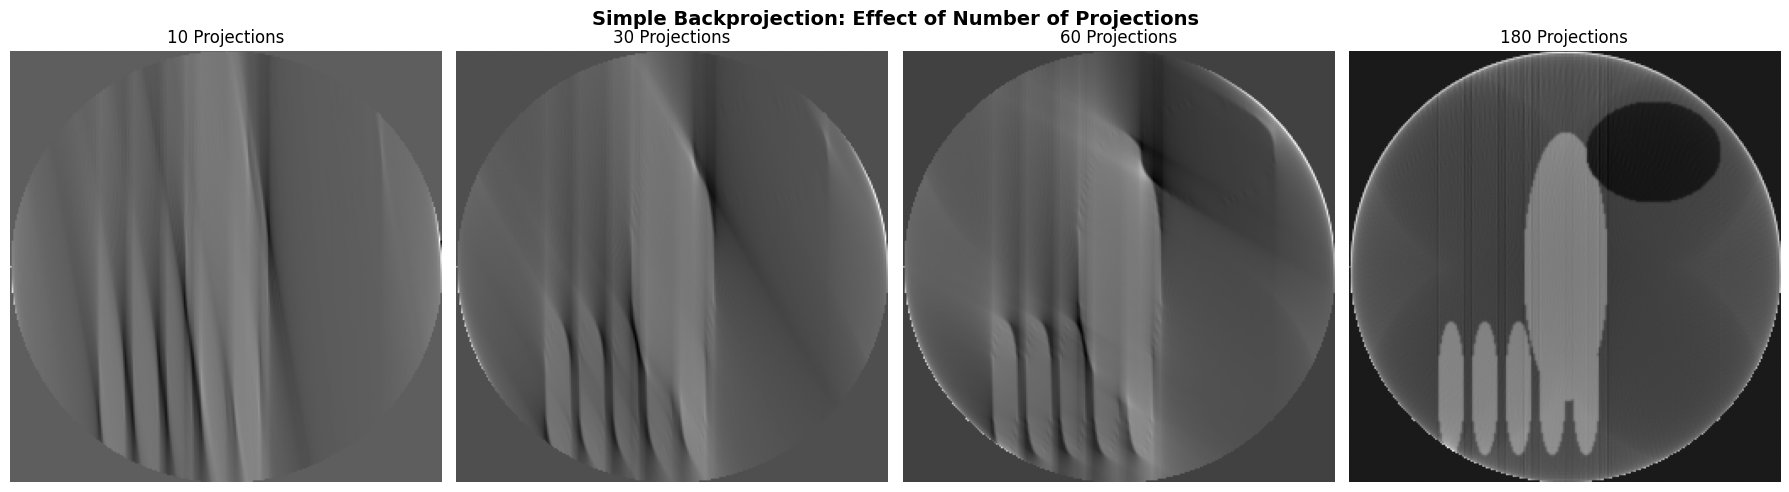


💡 Observation: More projections → Better quality
   But still blurry even with 180 projections!


In [47]:
# Compare 10, 30, 60, 180 projections
num_proj_list = [10, 30, 60, 180]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, num_proj in enumerate(num_proj_list):

    # Create sinogram with fewer projections
    sino_temp, theta_temp = create_sinogram(phantom_simple, num_angles=num_proj)

    # Reconstruct
    recon_temp = simple_backprojection(sino_temp, theta_temp)

    # Display
    axes[i].imshow(recon_temp, cmap='gray')
    axes[i].set_title(f'{num_proj} Projections', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Simple Backprojection: Effect of Number of Projections',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Observation: More projections → Better quality')
print('   But still blurry even with 180 projections!')

## 🎉 Part 2 Complete!

**What you learned:**
- ✅ Simple backprojection 'smears' projections back
- ✅ Creates blurry images with star artifacts
- ✅ More projections help, but not enough
- ✅ Filtering is ESSENTIAL!

---

# ✨ PART 3: Filtered Backprojection (25 min)

## Background

**Filtered Backprojection (FBP):**
1. Apply high-pass filter to each projection
2. Then backproject

**Common Filters:**
- **Ram-Lak:** Sharp but noisy
- **Shepp-Logan:** Balanced
- **Cosine:** Smooth
- **Hamming:** Low noise

**Result:** Sharp, clear images!

---

## Step 3.1: Implement Filtered Backprojection

**TODO:** Reconstruct using filtered backprojection

In [48]:
def filtered_backprojection(sinogram, theta, filter='ramp'):
    """
    Reconstruct image using filtered backprojection.

    Parameters:
    -----------
    sinogram : 2D array
        Input sinogram
    theta : 1D array
        Projection angles
    filter_name : str
        Filter type: 'ramp', 'shepp-logan', 'cosine', 'hamming'

    Returns:
    --------
    reconstruction : 2D array
        Reconstructed image
    """
    # Hint: Look up the documentation for the `iradon` function and use the filter_name parameter

    reconstruction = ski.transform.iradon(sinogram, theta, filter_name = filter)

    return reconstruction

# Test with Ram-Lak filter
recon_fbp = filtered_backprojection(sinogram_simple, angles, filter='ramp')

print(f'FBP reconstruction shape: {recon_fbp.shape}')
print(f'Value range: [{recon_fbp.min():.3f}, {recon_fbp.max():.3f}]')

FBP reconstruction shape: (256, 256)
Value range: [-0.126, 1.070]


## Step 3.2: Compare Simple BP vs FBP

**TODO:** Visualize the dramatic improvement!

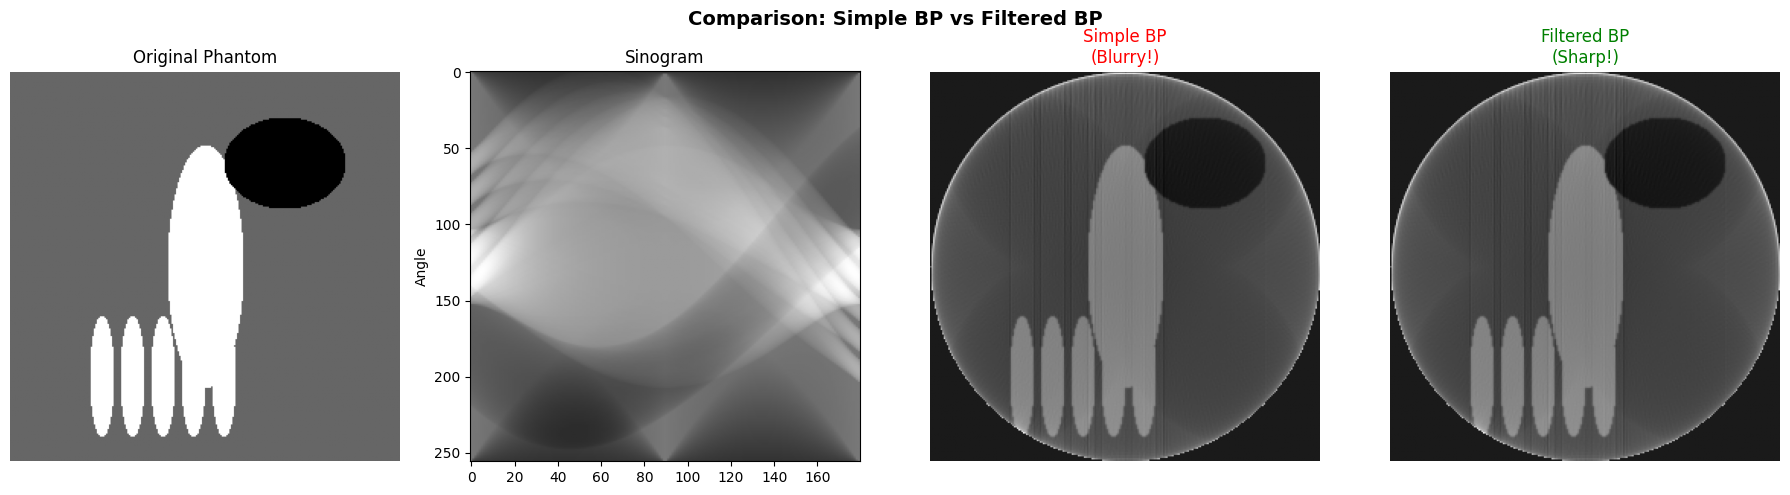


✓ FBP produces MUCH sharper images!
💡 This is why filtering is essential in CT!


In [49]:
# TODO: Create comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(phantom_simple, cmap='gray')
axes[0].set_title('Original Phantom', fontsize=12)
axes[0].axis('off')

# Sinogram
axes[1].imshow(sinogram_simple, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram', fontsize=12)
axes[1].set_ylabel('Angle')

# Simple backprojection
axes[2].imshow(recon_simple_bp, cmap='gray')
axes[2].set_title('Simple BP\n(Blurry!)', fontsize=12, color='red')
axes[2].axis('off')

# Filtered backprojection
axes[3].imshow(recon_fbp, cmap='gray')
axes[3].set_title('Filtered BP\n(Sharp!)', fontsize=12, color='green')
axes[3].axis('off')

plt.suptitle('Comparison: Simple BP vs Filtered BP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✓ FBP produces MUCH sharper images!')
print('💡 This is why filtering is essential in CT!')

## Step 3.3: Compare Different Filters

**TODO:** Try different filter types

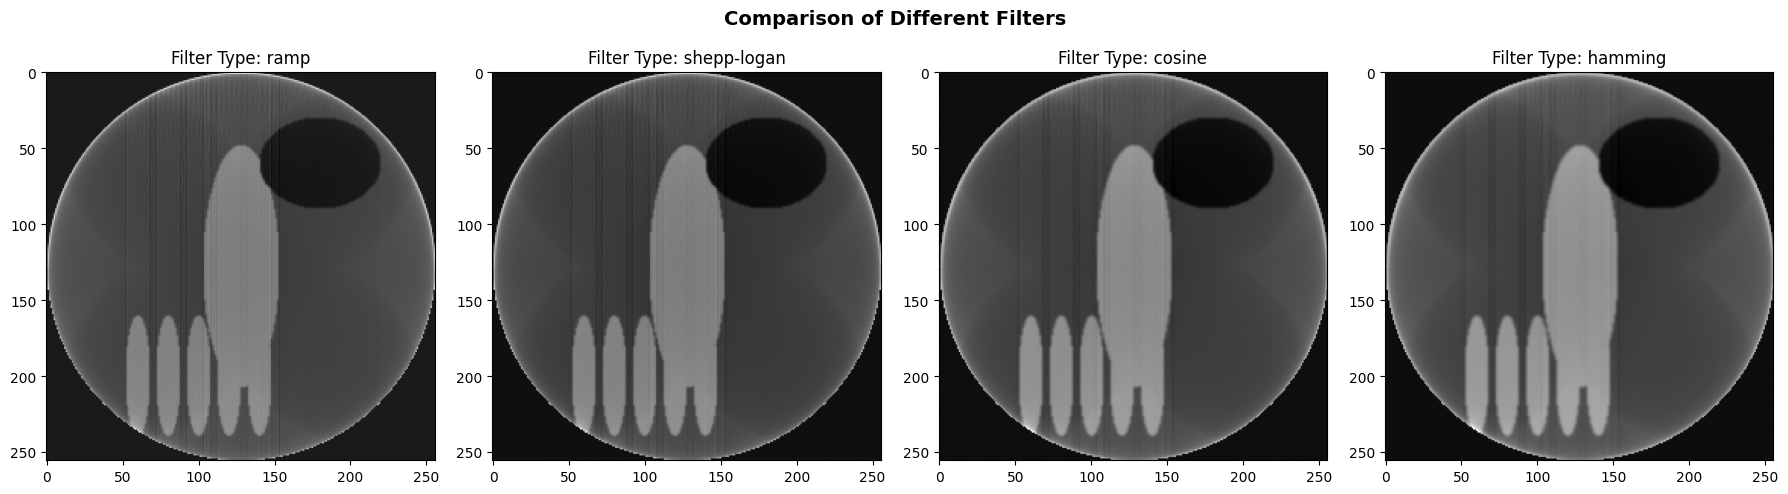

In [50]:
# TODO: Compare filters
filters = ['ramp', 'shepp-logan', 'cosine', 'hamming']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, filt in enumerate(filters):

    # Reconstruct with this filter
    recon = filtered_backprojection(sinogram_simple, angles, filter=filt)

    # Display
    axes[i].imshow(recon, cmap='gray')
    axes[i].set_title("Filter Type: {}".format(filt))

plt.suptitle('Comparison of Different Filters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3.4: Reconstruct All Phantoms with FBP

**TODO:** Apply FBP to hand and chest phantoms

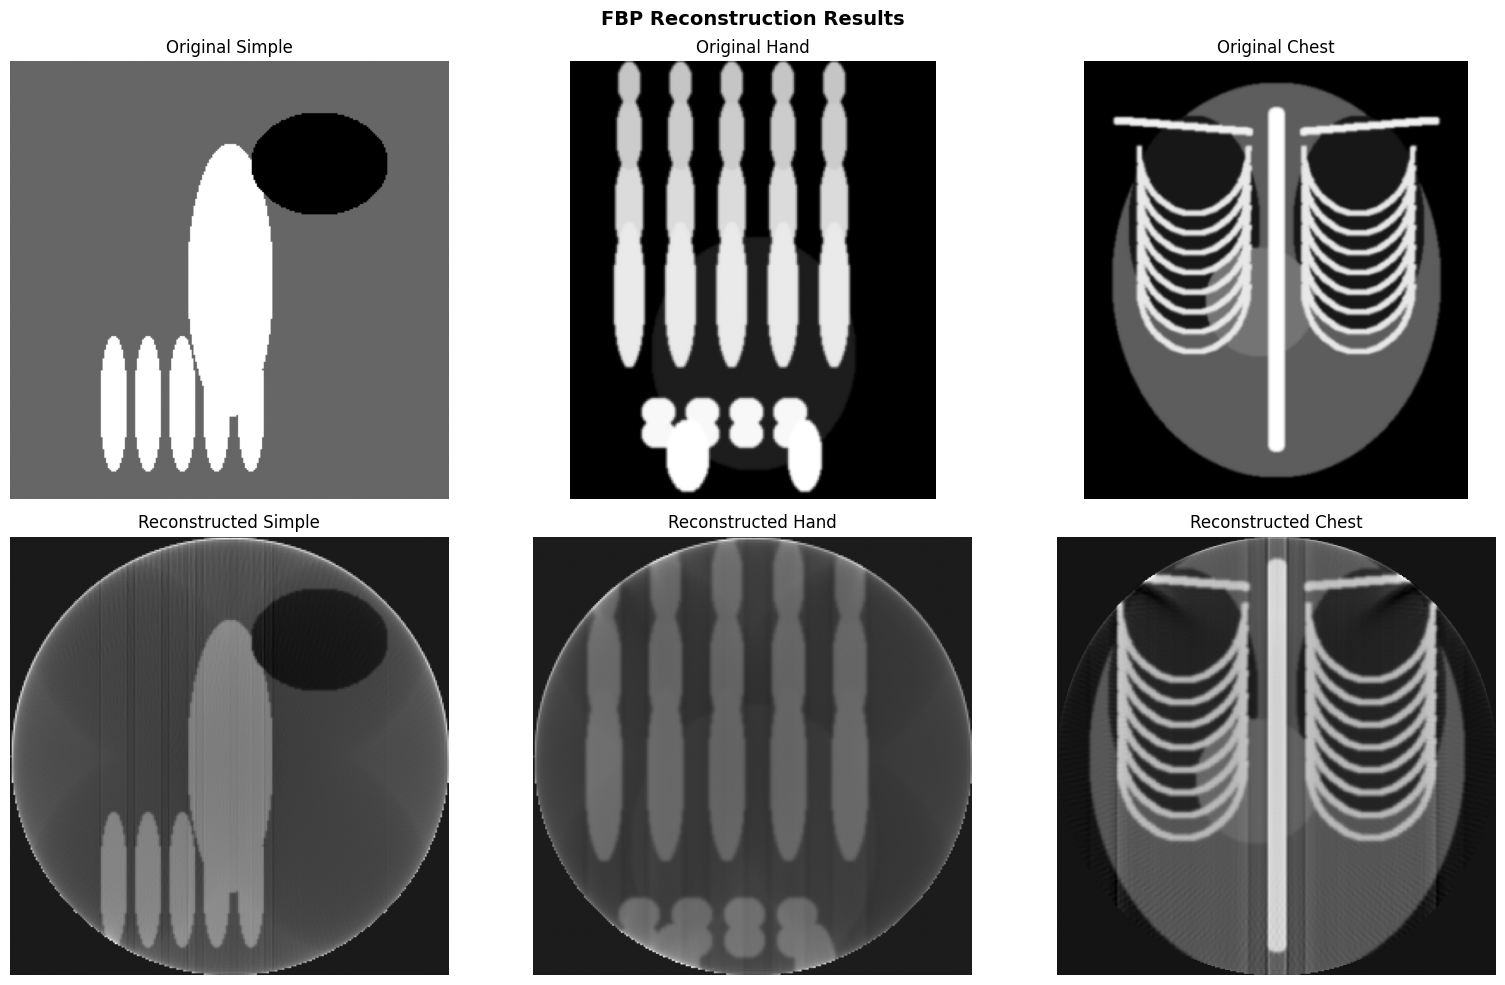

✓ All phantoms successfully reconstructed with FBP!


In [51]:
# TODO: Reconstruct all phantoms
recon_hand = filtered_backprojection(sinogram_hand, angles)
recon_chest = filtered_backprojection(sinogram_chest, angles)

# Display all reconstructions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Original phantoms
axes[0, 0].imshow(phantom_simple, cmap='gray')
axes[0, 0].set_title('Original Simple', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(hand_phantom, cmap='gray')
axes[0, 1].set_title('Original Hand', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(chest_phantom, cmap='gray')
axes[0, 2].set_title('Original Chest', fontsize=12)
axes[0, 2].axis('off')

# Row 2: FBP reconstructions
axes[1, 0].imshow(recon_fbp, cmap='gray')
axes[1, 0].set_title('Reconstructed Simple', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(recon_hand, cmap='gray')
axes[1, 1].set_title('Reconstructed Hand', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(recon_chest, cmap='gray')
axes[1, 2].set_title('Reconstructed Chest', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('FBP Reconstruction Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ All phantoms successfully reconstructed with FBP!')

## 🎉 Part 3 Complete!

**What you learned:**
- ✅ Filtering dramatically improves reconstruction
- ✅ Different filters offer different trade-offs
- ✅ FBP is the standard CT reconstruction method
- ✅ How real CT scanners work!

**Key insight:** This is exactly what happens in a real CT scanner!

---

# 📊 PART 4: Quality Analysis (20 min)

## Objective

Quantify reconstruction quality using:
- **MSE (Mean Squared Error):** Lower is better

---

## Step 4.1: Calculate Reconstruction Quality

**TODO:** Compute Mean Squared Error (MSE)

In [52]:
def calculate_MSE(original, reconstruction):

    """
    Calculate MSE between original and reconstruction.
    """
    # TODO: Calculate MSE (Look for the formula online)
    # Here your are not supposed to use any pre-built function, try to implement it yourself using basic numpy operations
    # Notice that image sizes may be different! Here you allowed to search for a function that will resize the reconstruction to match the original before calculating MSE

    x1, y1 = original.shape
    x2, y2 = reconstruction.shape

    if x1 != x2 or y1 != y2:

      reconstruction = np.resize(reconstruction, (x1, y1))

    sum = 0
    number_pixels = 0

    for linhas in range(0, len(reconstruction)):

      for colunas in range(0, len(reconstruction[0])):

        sum += (original[linhas][colunas] - reconstruction[linhas][colunas]) ** 2
        number_pixels += 1

    mse = sum / number_pixels

    return mse

# Compare simple BP vs FBP
mse_bp = calculate_MSE(phantom_simple, recon_simple_bp)
mse_fbp = calculate_MSE(phantom_simple, recon_fbp)

print('Reconstruction Quality Comparison:')
print('='*50)
print(f'Simple Backprojection:')
print(f'  MSE:  {mse_bp:.6f}')
print()
print(f'Filtered Backprojection:')
print(f'  MSE:  {mse_fbp:.6f} (↓ {(1-mse_fbp/mse_bp)*100:.1f}% improvement)')

Reconstruction Quality Comparison:
Simple Backprojection:
  MSE:  0.013785

Filtered Backprojection:
  MSE:  0.013785 (↓ 0.0% improvement)


## Step 4.2: Quality vs Number of Projections

**TODO:** Plot how reconstruction quality improves with more projections

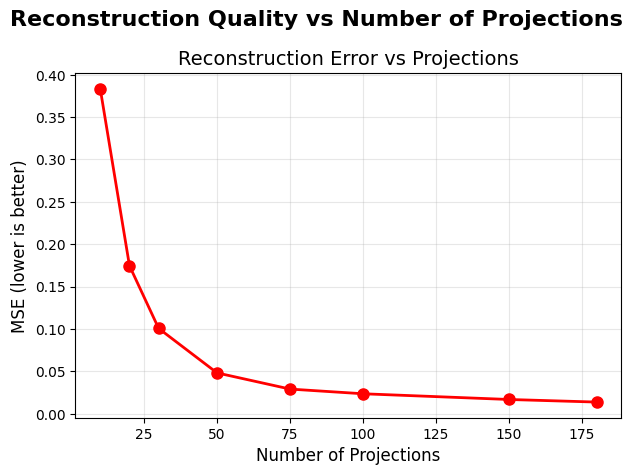

In [55]:
# TODO: Test different numbers of projections
proj_counts = [10, 20, 30, 50, 75, 100, 150, 180]
mse_values = []

for num_proj in proj_counts:
    # Create sinogram
    sino, theta = create_sinogram(phantom_simple, num_angles=num_proj)

    # Reconstruct
    recon = filtered_backprojection(sino, theta)

    # Calculate metrics
    mse = calculate_MSE(phantom_simple, recon)
    mse_values.append(mse)

# MSE plot
plt.plot(proj_counts, mse_values, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Projections', fontsize=12)
plt.ylabel('MSE (lower is better)', fontsize=12)
plt.title('Reconstruction Error vs Projections', fontsize=14)
plt.grid(True, alpha=0.3)

plt.suptitle('Reconstruction Quality vs Number of Projections',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 🎉 Lab Complete!

## Reflection Questions

**Q1:** How does the sinogram relate to the original phantom?

**Your answer:** The sinogram is nothing more than the compilation of views of the original phantom in different angular positionings in a single image.

**Q2:** Why does simple backprojection create blurry images?

**Your answer:** In the sinogram we have all angular projections in one single view. When backprojecting, we are manipulating the angular information into a new space and a new image. This transaction is not perfect since they're not in the same plane, so the result are some irregularities that take place in form of blur.

**Q3:** What is the purpose of filtering in FBP?

**Your answer:** The reconstruction helps to transform the sinograms (which are the image type colected by the curresponding machinery) in visible and comprehensible slices but, while doing it, the image becomes blurry and presents star artifacts that damages the image quality. To increase the image quality, filters can be applied to treat such blurs and artifacts.

**Q4:** What is the trade-off between number of projections and image quality?

**Your answer:** A lower number of projections gives us worst quality image while using less processing power. Increasing the number of projections also increases the quality of the image, but requires more processing.

**Q5:** Which filtering method yielded the best image quality ? Why do you think so ?

**Your answer:** Couldn't observe differences (probably error in code).

---

## 📚 Summary

### What You Accomplished Today:

✅ **Created sinograms** using Radon transform  
✅ **Implemented simple backprojection** (saw the blur!)  
✅ **Implemented filtered backprojection** (fixed the blur!)  
✅ **Quantified reconstruction quality** (MSE, SSIM)  
✅ **Understood how real CT scanners work**

### Connection to Real CT:

**Modern CT scanners:**
- Use 1000+ projections per slice
- Reconstruct in <1 second (GPUs!)
- Use iterative methods (not just FBP)
- Apply AI for denoising and artifact reduction


### Next Steps:

- **Next week:** CNNs for medical image analysis
- **Later:** Iterative reconstruction, AI denoising
- **Future:** PET, MRI, other modalities

---

**Congratulations!** 🎉  
You now understand the fundamental mathematics behind CT imaging!
